#Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

#Loading the Datasets

In [3]:
max_features = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words = max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Checking the shapes

In [4]:
print(x_train.shape)
print(x_test.shape)

(25000,)
(25000,)


#Pad Sequences

In [5]:
maxlen = 200
x_train = pad_sequences(x_train, maxlen = maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [6]:
print(x_train.shape)

(25000, 200)


#Building LSTM model

In [7]:
model = Sequential()
model.add(Embedding(input_dim = max_features,
                    output_dim = 128,
                    input_length = maxlen))
model.add(LSTM(64))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#Compile Model

In [8]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

#Model Summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Train Model

In [10]:
history = model.fit(x_train, y_train, epochs = 5, batch_size= 64, validation_split = 0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 281ms/step - accuracy: 0.7982 - loss: 0.4276 - val_accuracy: 0.8464 - val_loss: 0.3695
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 275ms/step - accuracy: 0.8984 - loss: 0.2621 - val_accuracy: 0.8534 - val_loss: 0.3542
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 279ms/step - accuracy: 0.9294 - loss: 0.1873 - val_accuracy: 0.8624 - val_loss: 0.3711
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - accuracy: 0.9509 - loss: 0.1335 - val_accuracy: 0.8532 - val_loss: 0.3886
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 282ms/step - accuracy: 0.9625 - loss: 0.1060 - val_accuracy: 0.8604 - val_loss: 0.4487


#Model Evaluation

In [11]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8596 - loss: 0.4529
Test Accuracy: 0.8596400022506714


#Graph 1(Accuracy Graph)

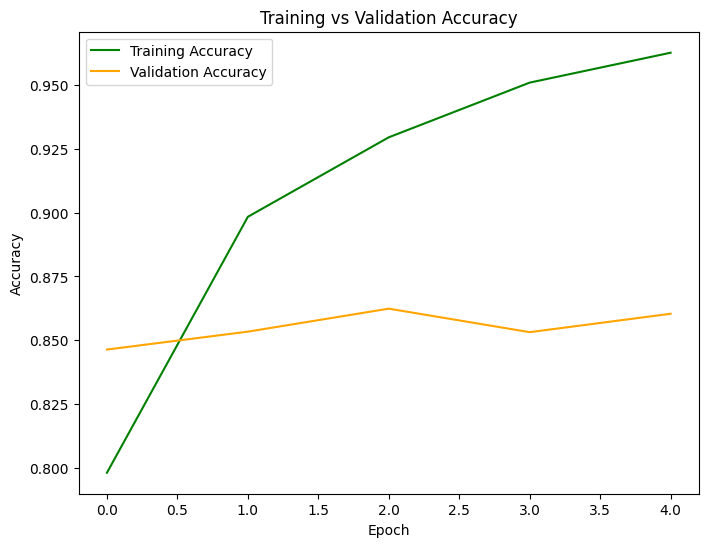

In [12]:
plt.figure(figsize = (8,6))
plt.plot(history.history["accuracy"], label = "Training Accuracy", color = "green")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy", color = "orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("Accuracy.png")
plt.show()

#Graph 2(Loss Graph)

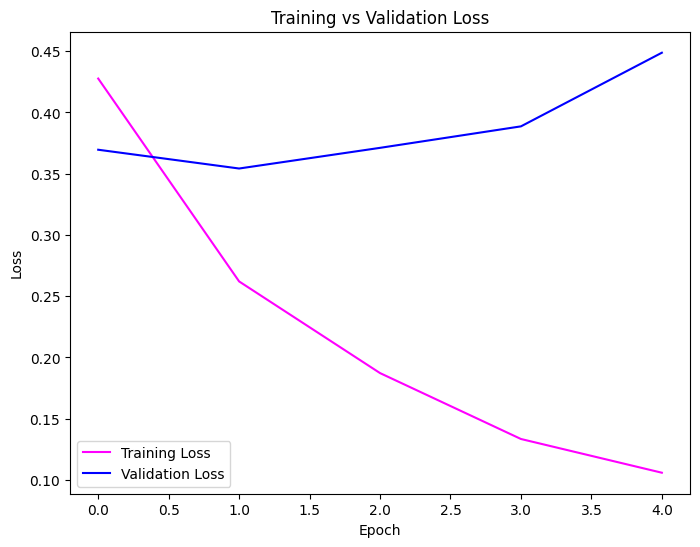

In [13]:
plt.figure(figsize = (8,6))
plt.plot(history.history["loss"], label = "Training Loss", color = "Magenta")
plt.plot(history.history["val_loss"], label = "Validation Loss", color = "Blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("loss.png")
plt.show()

#Model Saving

In [14]:
model.save("lstm_imdb.keras")

#Model Prediction

In [15]:
predictions = model.predict(x_test)
print(predictions)

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step
[[0.03      ]
 [0.999692  ]
 [0.06759776]
 ...
 [0.00287905]
 [0.01965247]
 [0.3311794 ]]


#Converting Probabilities into labels

In [23]:
predicted_labels = (predictions > 0.5).astype(int)

print(predicted_labels)

[[0]
 [1]
 [0]
 ...
 [0]
 [0]
 [0]]


#Comparing the labels

In [24]:
print("predicted Labels:")
print(predicted_labels.flatten())

print("actual Labels:")
print(y_test[:10])

predicted Labels:
[0 1 0 ... 0 0 0]
actual Labels:
[0 1 1 0 1 1 1 0 0 1]


#Flattening the prediction

In [18]:
predicted_labels = predicted_labels.flatten()

#Checking the shapes

In [19]:
print(y_test.shape)
print(predicted_labels.shape)

(25000,)
(25000,)


#Confusion Matrix

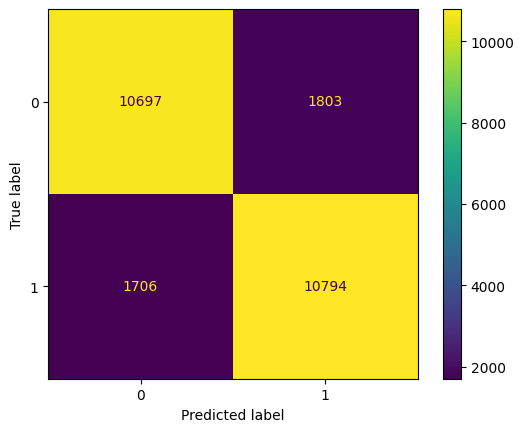

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

#Classification Report

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [25]:
from google.colab import files
files.download("Accuracy.png")
files.download("loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>